# 02 SQL within R Analysis and R Visualisation

This notebook uses R, SQLite, SQL queries, ggplot2 visualisations, and query optimisation to analyse the NorthStar datasets.

## 1. Setup

In [1]:
print("R is working")

[1] "R is working"


In [2]:
data_path <- "/content"
list.files(data_path)

[1] "app_events.csv"      "complaints.csv"      "customers.csv"      
 [4] "data_dictionary.csv" "deliveries.csv"      "drivers.csv"        
 [7] "hubs.csv"            "incidents.csv"       "orders.csv"         
[10] "README.txt"          "sample_data"         "vehicles.csv"

In [3]:
install.packages("readr")
install.packages("DBI")
install.packages("RSQLite")
install.packages("dplyr")
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message in install.packages("dplyr"):
“installation of package ‘dplyr’ had non-zero exit status”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
library(readr)
library(DBI)
library(RSQLite)
library(dplyr)
library(ggplot2)

print("Packages loaded successfully")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "Packages loaded successfully"


## 2. Load Data

In [5]:
orders <- read_csv(file.path(data_path, "orders.csv"))
deliveries <- read_csv(file.path(data_path, "deliveries.csv"))
complaints <- read_csv(file.path(data_path, "complaints.csv"))
hubs <- read_csv(file.path(data_path, "hubs.csv"))
drivers <- read_csv(file.path(data_path, "drivers.csv"))
vehicles <- read_csv(file.path(data_path, "vehicles.csv"))
incidents <- read_csv(file.path(data_path, "incidents.csv"))
customers <- read_csv(file.path(data_path, "customers.csv"))
app_events <- read_csv(file.path(data_path, "app_events.csv"))

print("CSV files loaded successfully")

Rows: 1250 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): order_id, customer_id, service_type, pickup_zone, dropoff_zone, pr...
dbl  (3): promised_window_hours, order_value, special_handling_flag
dttm (1): order_created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 950 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): delivery_id, order_id, driver_id, vehicle_id, hub_id, delivery_status
dbl  (5): route_distance_km, manual_route_override_count, proof_of_completio...
dttm (2): dispatch_time, delivery_completed_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 320 Columns: 10
── Column specification ─────────────────────────

[1] "CSV files loaded successfully"


In [6]:
head(orders)

order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
<chr>,<chr>,<chr>,<dttm>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>
O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0
O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,1


In [7]:
head(deliveries)

delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59,Failed,17.26,1,0,3.07,12.05
DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00,OnTime,10.34,1,0,5.00,13.41
DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32,OnTime,7.92,0,0,4.98,8.51
DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08,Delayed,16.42,0,0,4.18,13.62
DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34,OnTime,14.52,1,0,4.18,9.22
DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52,Delayed,13.84,0,0,1.57,9.58


In [8]:
head(complaints)

complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<chr>,<dbl>,<dbl>
CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18
CP0006,C0096,O00147,Delay,App,Medium,2024-07-22 07:43:00,Resolved,9,18.51


## 3. Prepare Delivery Duration

In [9]:
deliveries$dispatch_time <- as.POSIXct(deliveries$dispatch_time, format="%Y-%m-%d %H:%M:%S")
deliveries$delivery_completed_at <- as.POSIXct(deliveries$delivery_completed_at, format="%Y-%m-%d %H:%M:%S")

deliveries$delivery_duration_hours <- as.numeric(
  difftime(deliveries$delivery_completed_at, deliveries$dispatch_time, units = "hours")
)

head(deliveries)

delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_hours
<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59,Failed,17.26,1,0,3.07,12.05,22.149973
DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00,OnTime,10.34,1,0,5.00,13.41,-1.100000
DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32,OnTime,7.92,0,0,4.98,8.51,1.108991
DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08,Delayed,16.42,0,0,4.18,13.62,23.985584
DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34,OnTime,14.52,1,0,4.18,9.22,4.042814
DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52,Delayed,13.84,0,0,1.57,9.58,28.531218


## 4. Create SQLite Database

In [10]:
con <- dbConnect(SQLite(), ":memory:")

dbWriteTable(con, "orders", orders, overwrite = TRUE)
dbWriteTable(con, "deliveries", deliveries, overwrite = TRUE)
dbWriteTable(con, "complaints", complaints, overwrite = TRUE)
dbWriteTable(con, "hubs", hubs, overwrite = TRUE)
dbWriteTable(con, "drivers", drivers, overwrite = TRUE)
dbWriteTable(con, "vehicles", vehicles, overwrite = TRUE)
dbWriteTable(con, "incidents", incidents, overwrite = TRUE)
dbWriteTable(con, "customers", customers, overwrite = TRUE)
dbWriteTable(con, "app_events", app_events, overwrite = TRUE)

dbListTables(con)

[1] "app_events" "complaints" "customers"  "deliveries" "drivers"   
[6] "hubs"       "incidents"  "orders"     "vehicles"

## 5. SQL Queries

In [11]:
query_orders_by_hub <- "
SELECT
    h.hub_id,
    h.hub_name,
    h.zone,
    COUNT(o.order_id) AS total_orders
FROM orders o
LEFT JOIN hubs h
    ON LOWER(TRIM(o.pickup_zone)) = LOWER(TRIM(h.zone))
GROUP BY h.hub_id, h.hub_name, h.zone
ORDER BY total_orders DESC;
"

orders_by_hub <- dbGetQuery(con, query_orders_by_hub)
orders_by_hub

hub_id,hub_name,zone,total_orders
<chr>,<chr>,<chr>,<int>
H03,East Dock,East,207
H02,South Link,South,181
H01,North Exchange,North,174
H05,Central Core,Central,158
H08,Midtown Relay,Central,158
H04,West Gate,West,155
H07,Riverside Hub,Riverside,151
H06,Airport Hub,Airport,144
NA,NA,NA,80


In [12]:
query_failed_by_hub <- "
SELECT
    h.hub_id,
    h.hub_name,
    h.zone,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    ROUND(
        SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(d.delivery_id),
        2
    ) AS failure_rate_percent
FROM deliveries d
LEFT JOIN hubs h
    ON d.hub_id = h.hub_id
GROUP BY h.hub_id, h.hub_name, h.zone
ORDER BY failure_rate_percent DESC;
"

failed_by_hub <- dbGetQuery(con, query_failed_by_hub)
failed_by_hub

hub_id,hub_name,zone,total_deliveries,failed_deliveries,failure_rate_percent
<chr>,<chr>,<chr>,<int>,<int>,<dbl>
H08,Midtown Relay,Central,128,26,20.31
H05,Central Core,Central,115,23,20.00
H06,Airport Hub,Airport,104,15,14.42
H04,West Gate,West,127,16,12.60
H01,North Exchange,North,136,17,12.50
H07,Riverside Hub,Riverside,115,14,12.17
H02,South Link,South,106,10,9.43
H03,East Dock,East,119,11,9.24


In [13]:
query_duration_by_hub <- "
SELECT
    h.hub_name,
    h.zone,
    ROUND(AVG(d.delivery_duration_hours), 2) AS average_delivery_hours,
    COUNT(d.delivery_id) AS total_deliveries
FROM deliveries d
LEFT JOIN hubs h
    ON d.hub_id = h.hub_id
GROUP BY h.hub_name, h.zone
ORDER BY average_delivery_hours DESC;
"

duration_by_hub <- dbGetQuery(con, query_duration_by_hub)
duration_by_hub

hub_name,zone,average_delivery_hours,total_deliveries
<chr>,<chr>,<dbl>,<int>
Central Core,Central,10.90,115
West Gate,West,10.33,127
Riverside Hub,Riverside,9.92,115
Midtown Relay,Central,9.82,128
Airport Hub,Airport,9.38,104
North Exchange,North,9.38,136
South Link,South,8.87,106
East Dock,East,7.66,119


In [14]:
query_complaints_by_type <- "
SELECT
    complaint_type,
    COUNT(complaint_id) AS total_complaints
FROM complaints
GROUP BY complaint_type
ORDER BY total_complaints DESC;
"

complaints_by_type <- dbGetQuery(con, query_complaints_by_type)
complaints_by_type

complaint_type,total_complaints
<chr>,<int>
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15


In [15]:
query_complaints_by_service <- "
SELECT
    o.service_type,
    COUNT(c.complaint_id) AS total_complaints
FROM complaints c
LEFT JOIN orders o
    ON c.order_id = o.order_id
GROUP BY o.service_type
ORDER BY total_complaints DESC;
"

complaints_by_service <- dbGetQuery(con, query_complaints_by_service)
complaints_by_service

service_type,total_complaints
<chr>,<int>
Passenger,84
Retail,83
Parcel,77
Business,39
Medical,37


In [16]:
query_overrides_by_status <- "
SELECT
    delivery_status,
    COUNT(delivery_id) AS total_deliveries,
    ROUND(AVG(manual_route_override_count), 2) AS average_manual_overrides
FROM deliveries
GROUP BY delivery_status
ORDER BY average_manual_overrides DESC;
"

overrides_by_status <- dbGetQuery(con, query_overrides_by_status)
overrides_by_status

delivery_status,total_deliveries,average_manual_overrides
<chr>,<int>,<dbl>
Delayed,202,1.07
Failed,132,1.04
OnTime,616,0.92


In [17]:
query_driver_performance <- "
SELECT
    dr.driver_id,
    dr.base_zone,
    ROUND(AVG(dr.driver_rating), 2) AS average_driver_rating,
    ROUND(AVG(dr.training_score), 2) AS average_training_score,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    ROUND(
        SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(d.delivery_id),
        2
    ) AS failure_rate_percent
FROM deliveries d
LEFT JOIN drivers dr
    ON d.driver_id = dr.driver_id
GROUP BY dr.driver_id, dr.base_zone
ORDER BY failure_rate_percent DESC
LIMIT 10;
"

driver_performance <- dbGetQuery(con, query_driver_performance)
driver_performance

driver_id,base_zone,average_driver_rating,average_training_score,total_deliveries,failed_deliveries,failure_rate_percent
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>
D051,WEST,3.58,75.4,2,2,100.00
D063,north,4.03,85.7,3,2,66.67
D092,East,4.24,88.2,5,3,60.00
D104,WEST,3.45,87.7,7,4,57.14
D024,RiverSide,3.35,71.4,8,4,50.00
D103,Central,4.40,72.5,4,2,50.00
D111,Airport,4.12,79.2,4,2,50.00
D132,South,4.20,77.6,4,2,50.00
D147,West,3.80,66.4,2,1,50.00


In [18]:
query_vehicle_incidents <- "
SELECT
    v.vehicle_id,
    v.vehicle_type,
    ROUND(AVG(v.battery_health_pct), 2) AS battery_health_pct,
    ROUND(AVG(v.odometer_km), 2) AS odometer_km,
    COUNT(DISTINCT d.delivery_id) AS total_deliveries,
    COUNT(i.incident_id) AS total_incidents
FROM vehicles v
LEFT JOIN deliveries d
    ON v.vehicle_id = d.vehicle_id
LEFT JOIN incidents i
    ON d.delivery_id = i.delivery_id
GROUP BY v.vehicle_id, v.vehicle_type
ORDER BY total_incidents DESC
LIMIT 10;
"

vehicle_incidents <- dbGetQuery(con, query_vehicle_incidents)
vehicle_incidents

vehicle_id,vehicle_type,battery_health_pct,odometer_km,total_deliveries,total_incidents
<chr>,<chr>,<dbl>,<dbl>,<int>,<int>
V047,EV,93.7,134347,17,9
V108,Diesel,54.6,141290,9,7
V030,CargoVan,78.0,134360,15,6
V046,EV,95.8,101425,10,6
V097,EV,92.1,18680,8,6
V005,CargoVan,58.6,146638,13,5
V009,CargoVan,68.8,156687,9,5
V035,CargoVan,83.6,73804,9,5
V042,EV,80.5,215870,13,5


In [19]:
query_integrated_view <- "
SELECT
    o.order_id,
    o.customer_id,
    o.service_type,
    o.pickup_zone,
    o.dropoff_zone,
    d.delivery_status,
    ROUND(d.delivery_duration_hours, 2) AS delivery_duration_hours,
    d.manual_route_override_count,
    c.complaint_type,
    c.severity AS complaint_severity,
    h.hub_name,
    h.zone
FROM orders o
LEFT JOIN deliveries d
    ON o.order_id = d.order_id
LEFT JOIN complaints c
    ON o.order_id = c.order_id
LEFT JOIN hubs h
    ON d.hub_id = h.hub_id
LIMIT 20;
"

integrated_view <- dbGetQuery(con, query_integrated_view)
integrated_view

order_id,customer_id,service_type,pickup_zone,dropoff_zone,delivery_status,delivery_duration_hours,manual_route_override_count,complaint_type,complaint_severity,hub_name,zone
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
O00001,C0292,Passenger,Airport,South,OnTime,2.40,2,NA,NA,North Exchange,North
O00002,C0459,Passenger,North,AIRPORT,NA,NA,NA,NA,NA,NA,NA
O00003,C0161,Passenger,West,AIRPORT,Delayed,8.86,2,AppIssue,Medium,South Link,South
O00004,C0520,Parcel,RiverSide,North,OnTime,-1.10,1,NA,NA,South Link,South
O00005,C0558,Retail,Riverside,SOUTH,OnTime,11.70,1,MissedPickup,Medium,East Dock,East
O00006,C0437,Retail,CENTRAL,East,NA,NA,NA,NA,NA,NA,NA
O00007,C0001,Business,CENTRAL,Airport,Delayed,8.92,1,AppIssue,High,Airport Hub,Airport
O00008,C0157,Parcel,Riverside,Riverside,OnTime,0.42,0,MissedPickup,Medium,East Dock,East
O00009,C0141,Retail,NORTH,East,OnTime,9.75,0,NA,NA,North Exchange,North


## 6. SQL Indexing and Explain Query Plan

In [20]:
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_orders_order_id ON orders(order_id);")
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_deliveries_order_id ON deliveries(order_id);")
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_complaints_order_id ON complaints(order_id);")
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_deliveries_hub_id ON deliveries(hub_id);")
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_deliveries_driver_id ON deliveries(driver_id);")
dbExecute(con, "CREATE INDEX IF NOT EXISTS idx_deliveries_vehicle_id ON deliveries(vehicle_id);")

print("Indexes created successfully")

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

[1] 0

[1] "Indexes created successfully"


In [21]:
query_plan <- dbGetQuery(con, "
EXPLAIN QUERY PLAN
SELECT
    o.order_id,
    o.service_type,
    d.delivery_status,
    c.complaint_type
FROM orders o
LEFT JOIN deliveries d
    ON o.order_id = d.order_id
LEFT JOIN complaints c
    ON o.order_id = c.order_id
WHERE d.hub_id = 'H01';
")

query_plan

id,parent,notused,detail
<int>,<int>,<int>,<chr>
7,0,61,SEARCH d USING INDEX idx_deliveries_hub_id (hub_id=?)
12,0,61,SEARCH o USING INDEX idx_orders_order_id (order_id=?)
18,0,61,SEARCH c USING INDEX idx_complaints_order_id (order_id=?) LEFT-JOIN


## 7. R Analytics and Visualisation

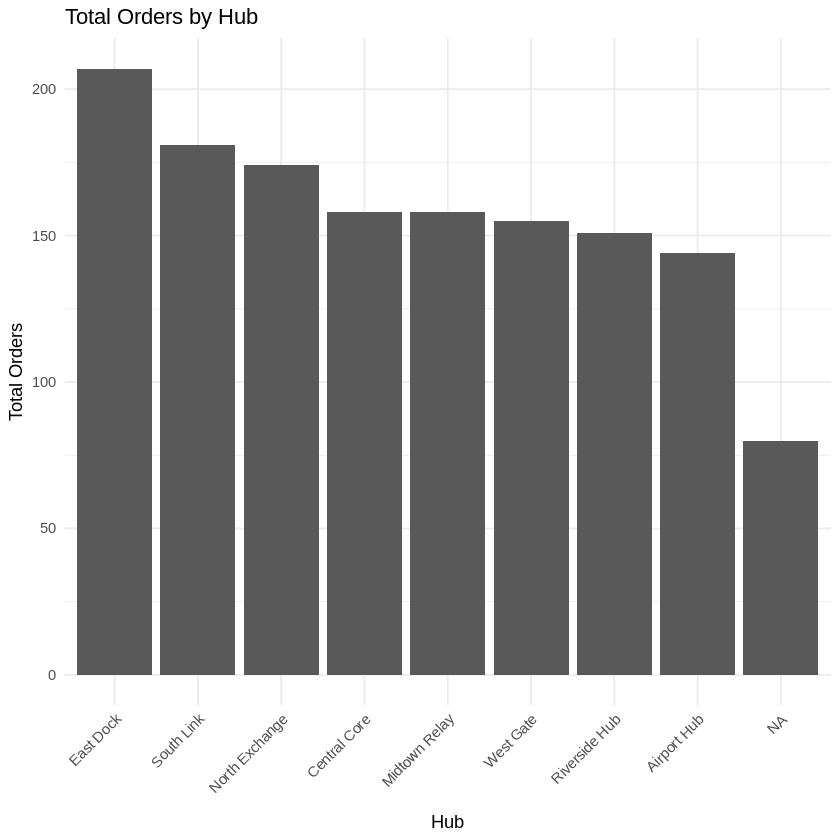

In [22]:
ggplot(orders_by_hub, aes(x = reorder(hub_name, -total_orders), y = total_orders)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Total Orders by Hub",
    x = "Hub",
    y = "Total Orders"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

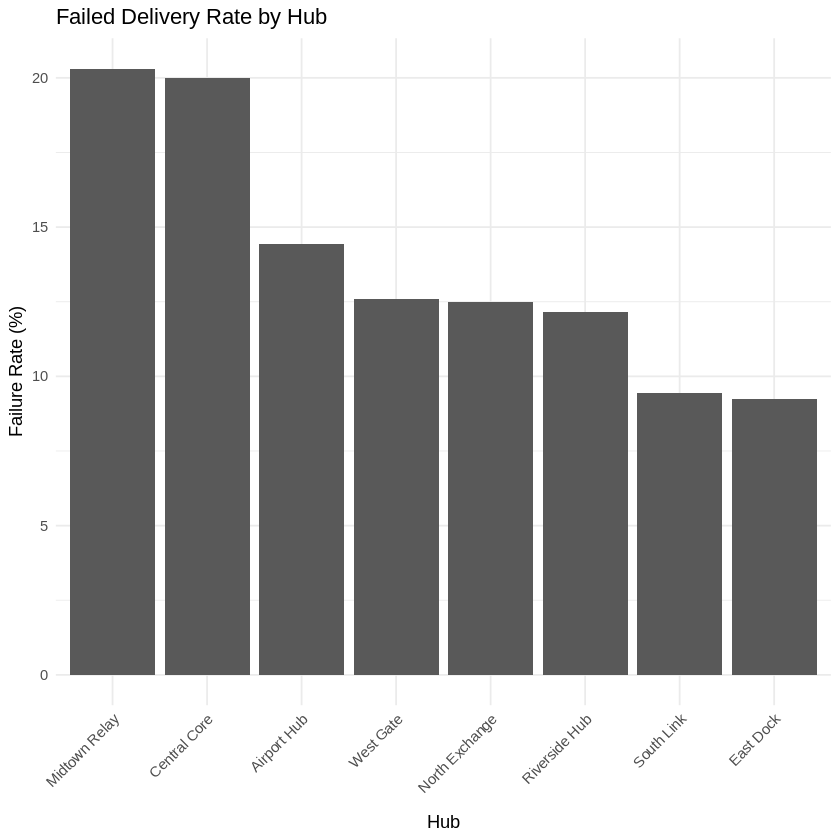

In [23]:
ggplot(failed_by_hub, aes(x = reorder(hub_name, -failure_rate_percent), y = failure_rate_percent)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Failed Delivery Rate by Hub",
    x = "Hub",
    y = "Failure Rate (%)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

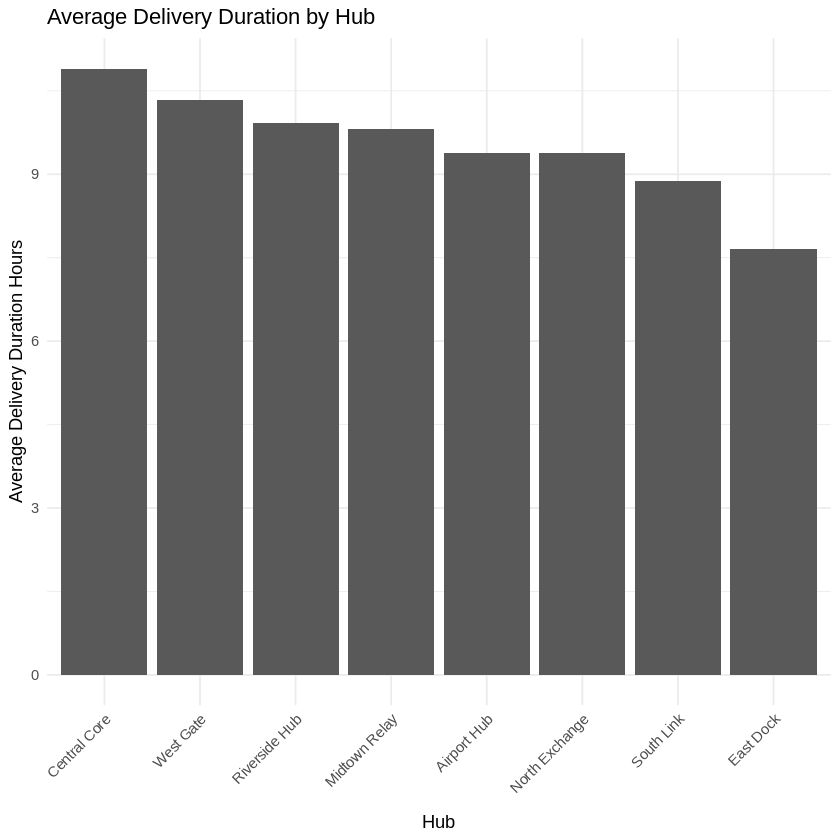

In [24]:
ggplot(duration_by_hub, aes(x = reorder(hub_name, -average_delivery_hours), y = average_delivery_hours)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Average Delivery Duration by Hub",
    x = "Hub",
    y = "Average Delivery Duration Hours"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

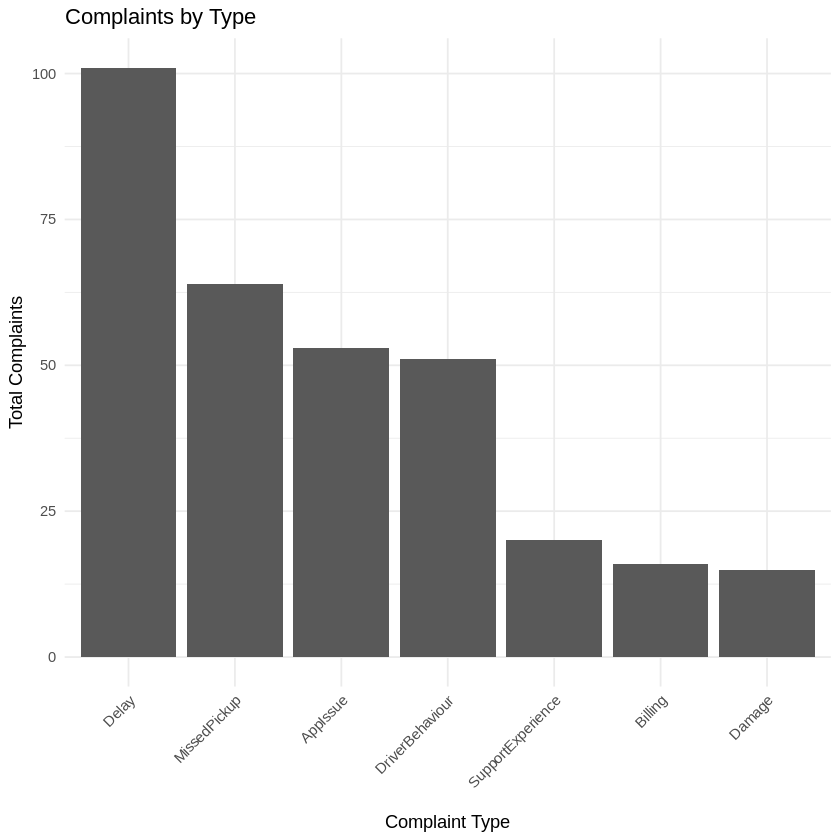

In [25]:
ggplot(complaints_by_type, aes(x = reorder(complaint_type, -total_complaints), y = total_complaints)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Complaints by Type",
    x = "Complaint Type",
    y = "Total Complaints"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

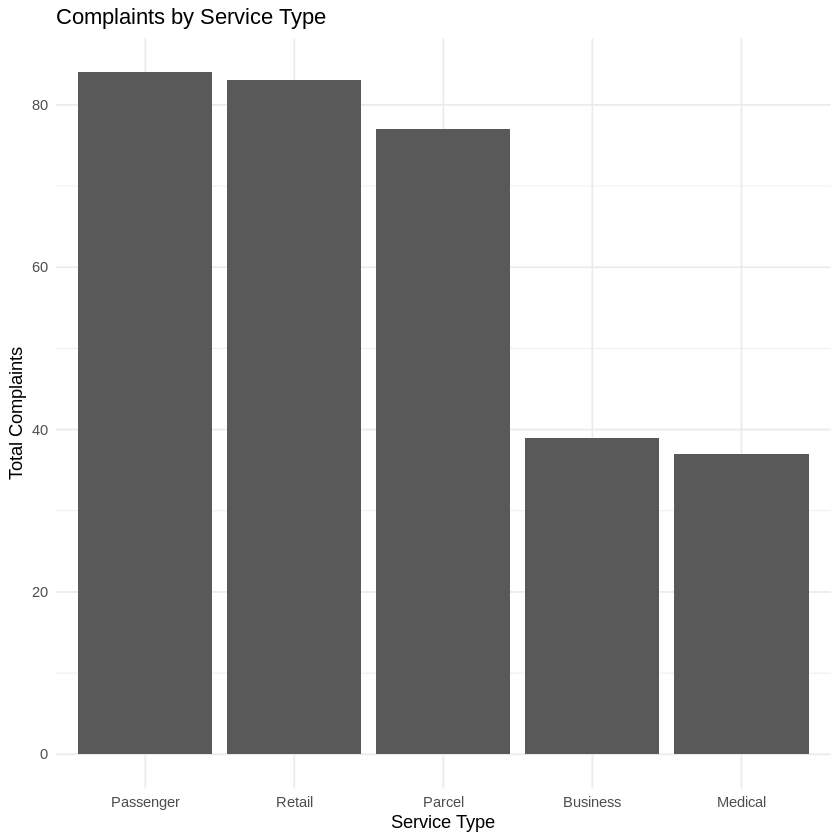

In [26]:
ggplot(complaints_by_service, aes(x = reorder(service_type, -total_complaints), y = total_complaints)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Complaints by Service Type",
    x = "Service Type",
    y = "Total Complaints"
  ) +
  theme_minimal()

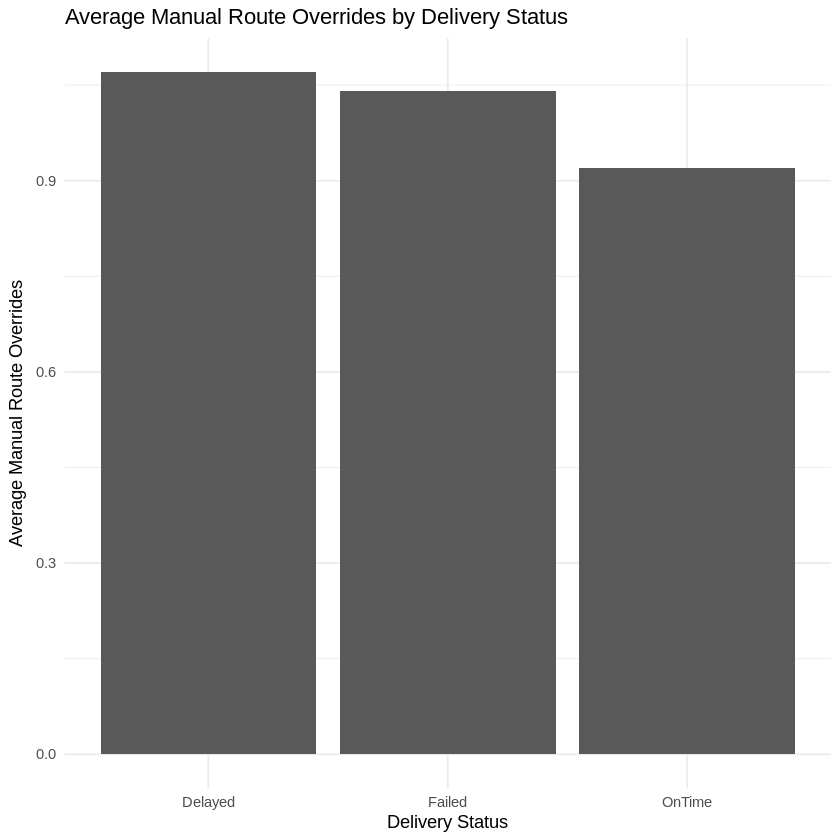

In [27]:
ggplot(overrides_by_status, aes(x = delivery_status, y = average_manual_overrides)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Average Manual Route Overrides by Delivery Status",
    x = "Delivery Status",
    y = "Average Manual Route Overrides"
  ) +
  theme_minimal()

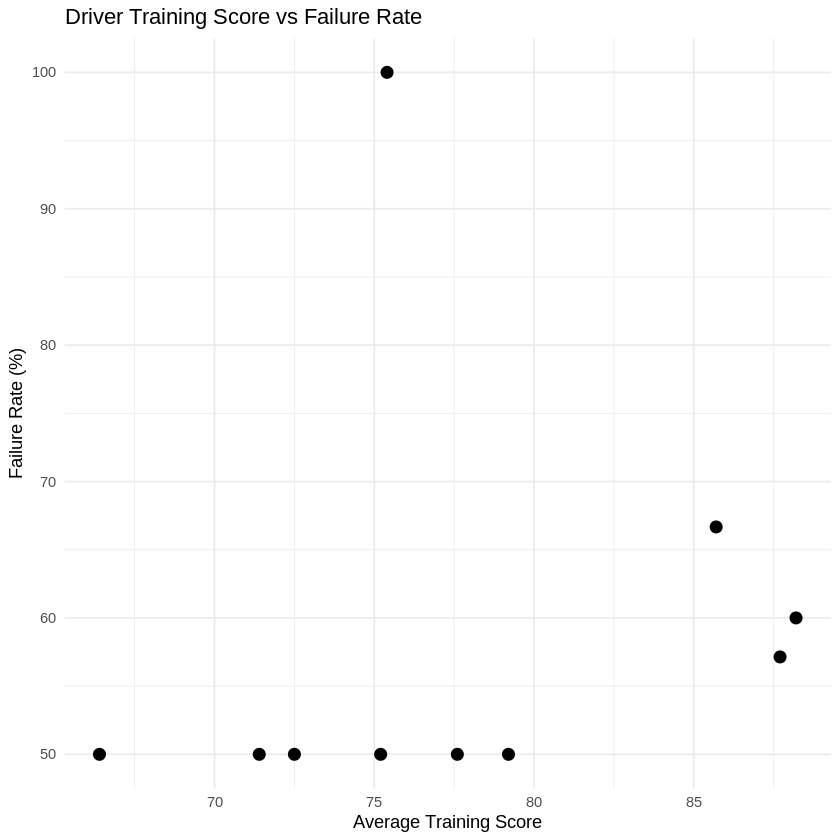

In [28]:
ggplot(driver_performance, aes(x = average_training_score, y = failure_rate_percent)) +
  geom_point(size = 3) +
  labs(
    title = "Driver Training Score vs Failure Rate",
    x = "Average Training Score",
    y = "Failure Rate (%)"
  ) +
  theme_minimal()

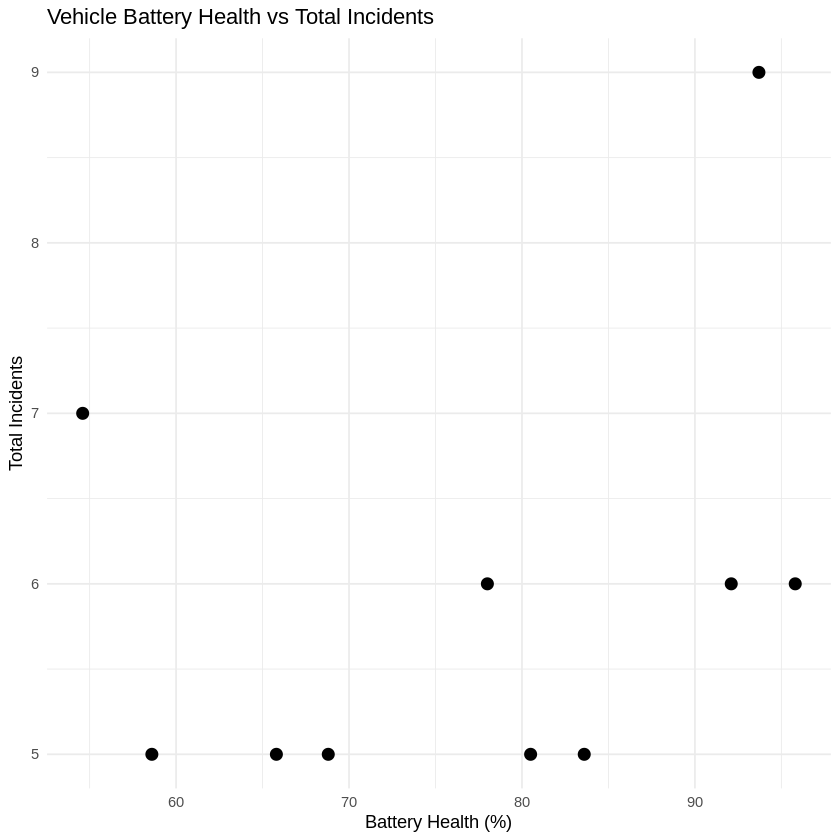

In [29]:
ggplot(vehicle_incidents, aes(x = battery_health_pct, y = total_incidents)) +
  geom_point(size = 3) +
  labs(
    title = "Vehicle Battery Health vs Total Incidents",
    x = "Battery Health (%)",
    y = "Total Incidents"
  ) +
  theme_minimal()

In [30]:
summary(deliveries$delivery_duration_hours)
summary(drivers$training_score)
summary(vehicles$battery_health_pct)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
 -2.214   2.946   7.074   9.545  14.644  43.457      19 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  40.60   68.55   75.20   74.91   82.75   99.00       7 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  42.00   68.20   78.05   76.79   85.78  100.00       4 

In [31]:
delivery_status_stats <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(
    total_deliveries = n(),
    average_duration_hours = round(mean(delivery_duration_hours, na.rm = TRUE), 2),
    median_duration_hours = round(median(delivery_duration_hours, na.rm = TRUE), 2)
  ) %>%
  arrange(desc(average_duration_hours))

delivery_status_stats

delivery_status,total_deliveries,average_duration_hours,median_duration_hours
<chr>,<int>,<dbl>,<dbl>
Failed,132,17.78,16.64
Delayed,202,13.51,12.45
OnTime,616,6.49,3.82


Warning message:
“Removed 19 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


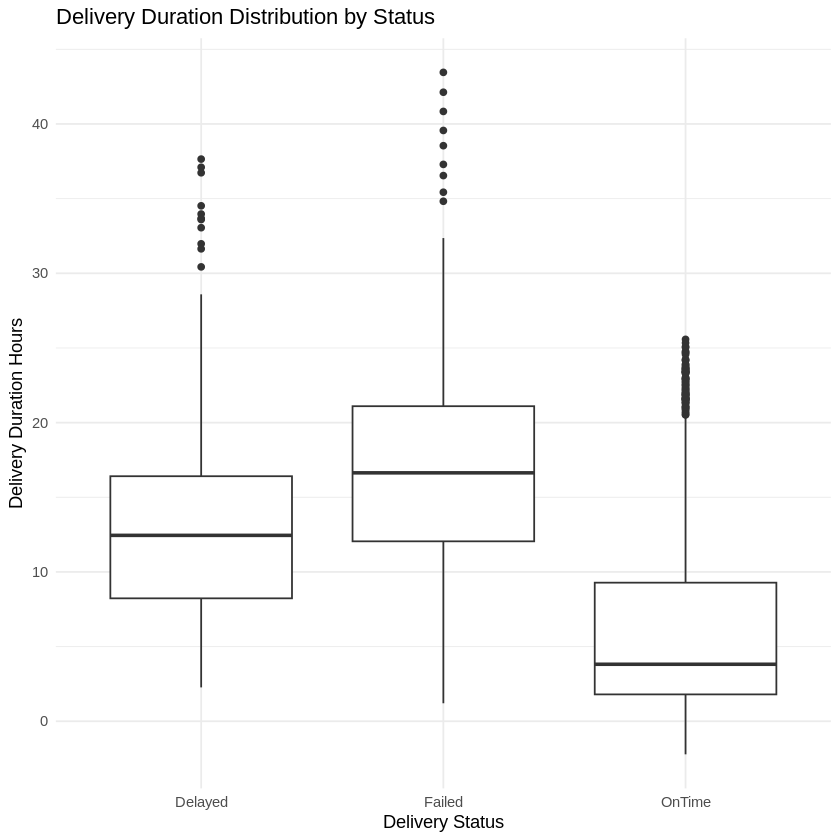

In [32]:
ggplot(deliveries, aes(x = delivery_status, y = delivery_duration_hours)) +
  geom_boxplot() +
  labs(
    title = "Delivery Duration Distribution by Status",
    x = "Delivery Status",
    y = "Delivery Duration Hours"
  ) +
  theme_minimal()